In [ ]:
!pip install snowflake-connector-python pandas scikit-learn

In [ ]:
import snowflake.connector
import pandas as pd

In [ ]:
conn = snowflake.connector.connect(
    user='user',
    password='password',
    account='ZZMYRGD-HP57295',
    database='WATERPOTABILITY',
    schema='PUBLIC',
    warehouse='COMPUTE_WH'
)

In [ ]:
query = "SELECT * FROM WATERPOTABLE"
df = pd.read_sql(query, conn)

/tmp/ipykernel_8045/1593983056.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [ ]:
conn.close()
print(df.head())

         PH    HARDNESS       SOLIDS  CHLORAMINES     SULFATE  CONDUCTIVITY  \
0       NaN  204.890456  20791.31898     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.05786     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.54173     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.41744     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.98634     6.546600  310.135738    398.410813   

   ORGANIC_CARBON  TRIHALOMETHANES  TURBIDITY  POTABILITY  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436525       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  


In [ ]:
df1=df.copy()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PH               2785 non-null   float64
 1   HARDNESS         3276 non-null   float64
 2   SOLIDS           3276 non-null   float64
 3   CHLORAMINES      3276 non-null   float64
 4   SULFATE          2495 non-null   float64
 5   CONDUCTIVITY     3276 non-null   float64
 6   ORGANIC_CARBON   3276 non-null   float64
 7   TRIHALOMETHANES  3114 non-null   float64
 8   TURBIDITY        3276 non-null   float64
 9   POTABILITY       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
df.isnull().sum()

,0
PH,491
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,781
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,162
TURBIDITY,0
POTABILITY,0


In [ ]:
df.describe()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690300,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833605,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762125,8.114887,359.950170,481.792305,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196010,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [ ]:
df.shape

(3276, 10)

In [ ]:
import missingno as msno

<Axes: >

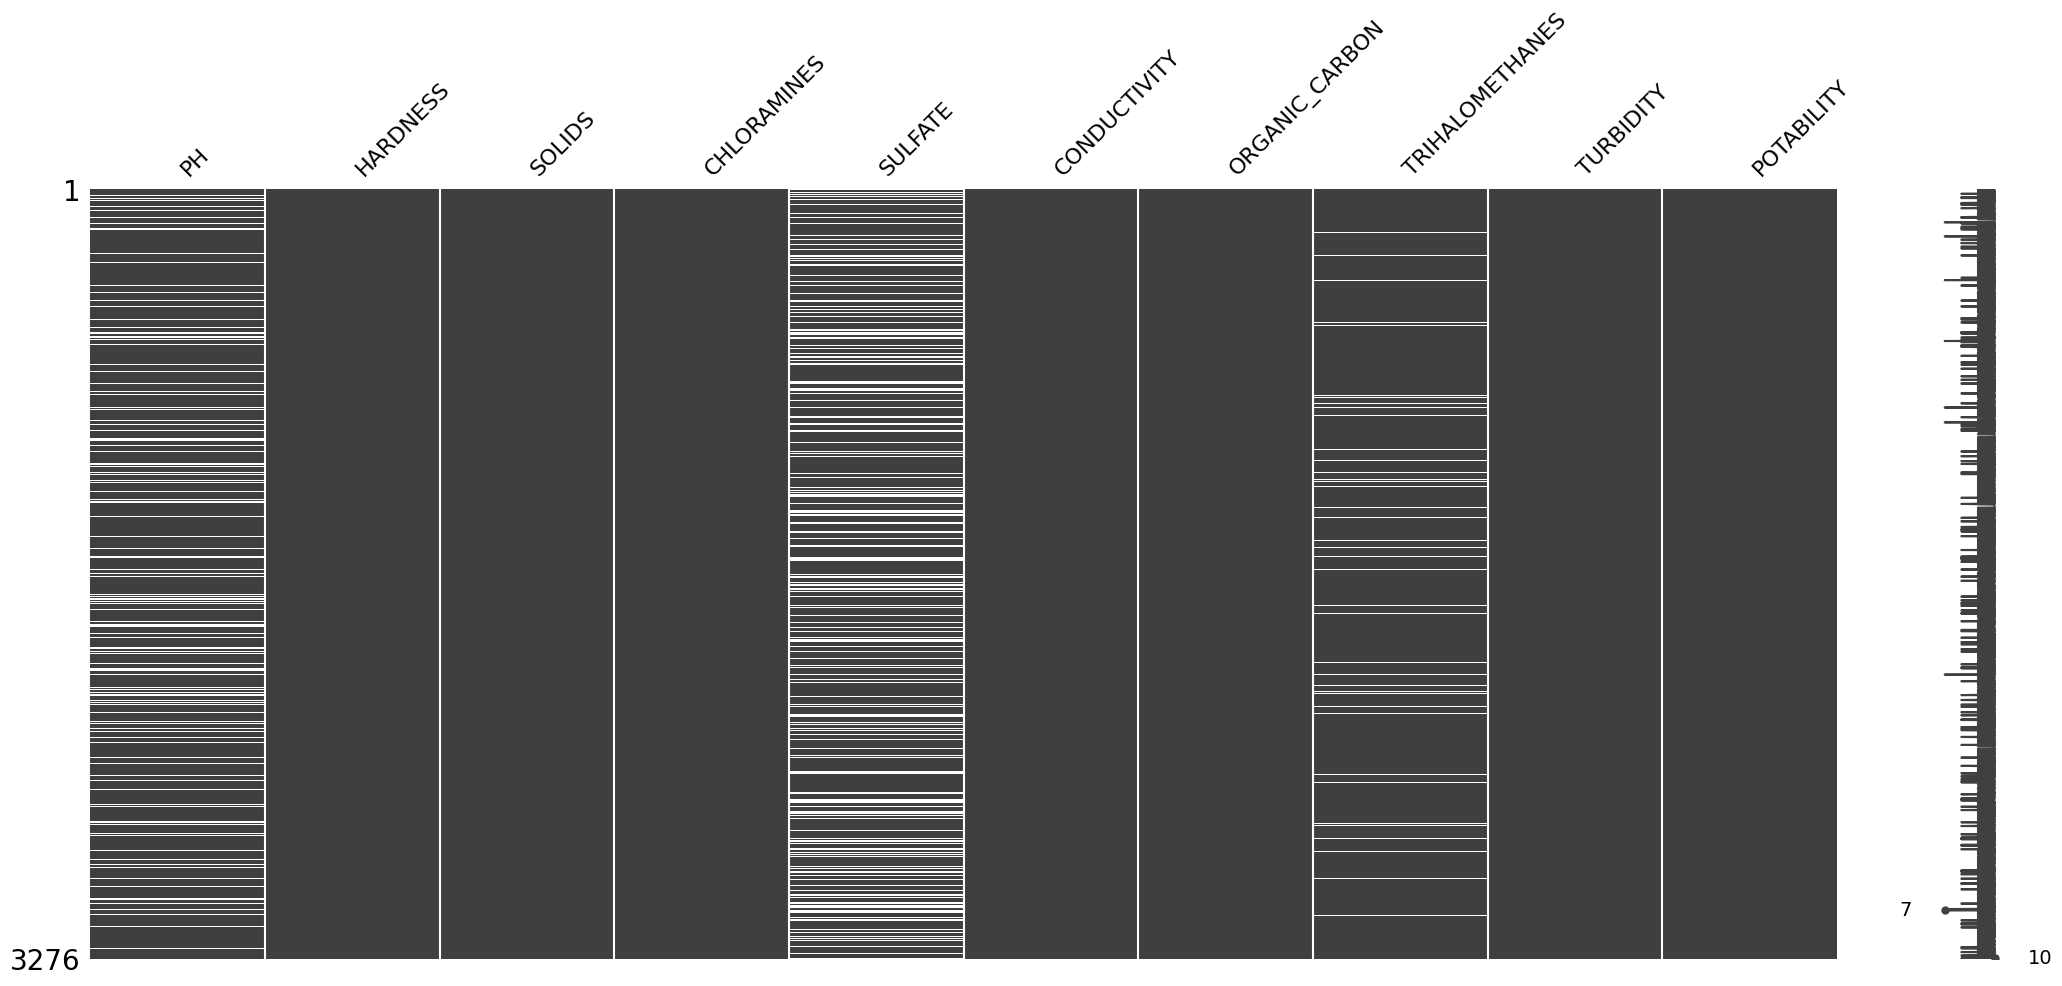

In [ ]:
msno.matrix(df)

<Axes: >

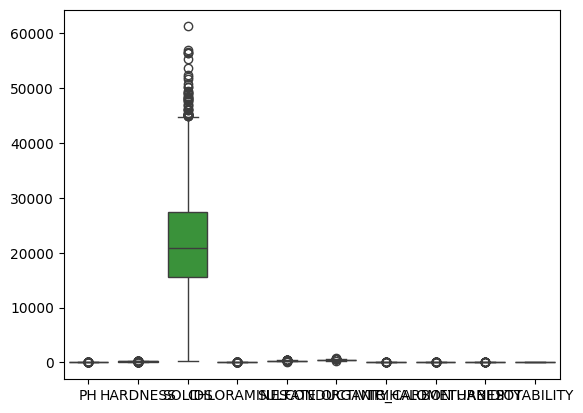

In [ ]:
import seaborn as sns

sns.boxplot(df)

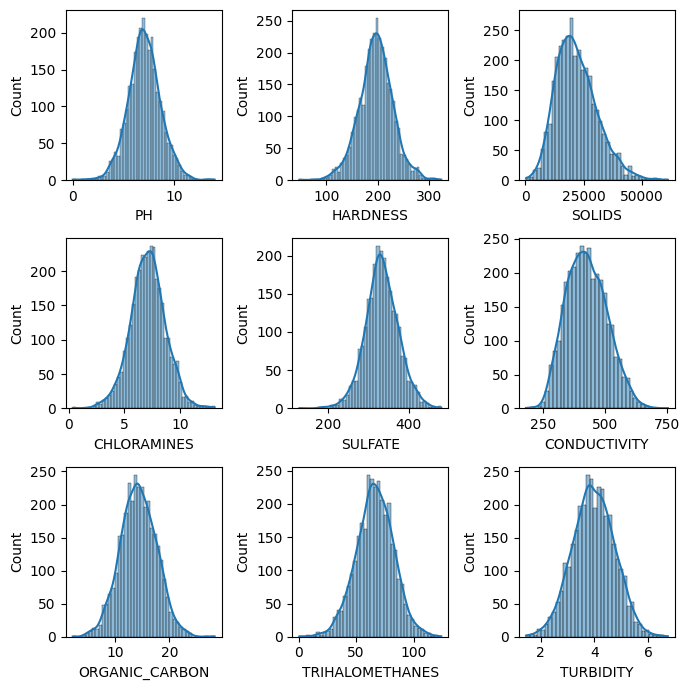

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3, 3, figsize=(7, 7))
axes_list = ax.flatten()

for col, current_ax in zip(df.columns, axes_list):
    sns.histplot(df[col], kde=True, ax=current_ax)

plt.tight_layout()
plt.show()

In [ ]:
df.skew()

,0
PH,0.025630
HARDNESS,-0.039342
SOLIDS,0.621634
CHLORAMINES,-0.012098
SULFATE,-0.035947
CONDUCTIVITY,0.264490
ORGANIC_CARBON,0.025533
TRIHALOMETHANES,-0.083031
TURBIDITY,-0.007817
POTABILITY,0.450784


In [ ]:
import numpy as np
from scipy.stats import zscore
dr=df.drop('SOLIDS',axis=1)
z_scores=zscore(dr)
dr[np.abs(z_scores)>2.5]

,PH,HARDNESS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
18,8.975464,279.357167,6.204321,NaN,431.443990,12.888759,63.821237,2.436086,0
29,NaN,148.153061,9.046833,307.011793,563.804743,16.568656,52.676185,6.038185,0
37,5.618064,304.235912,6.101084,NaN,399.471566,12.265002,81.588992,2.896547,0
43,9.920691,202.817483,6.882248,337.350529,333.192470,23.917601,71.833624,4.690707,0
51,7.809632,100.457615,5.212315,247.200826,605.220124,9.611349,66.084174,2.447444,0
...,...,...,...,...,...,...,...,...,...
3218,5.859822,287.975540,4.072626,391.697385,447.121861,6.363175,49.155291,3.426634,1
3221,4.034063,303.702627,4.425559,NaN,494.320907,13.415230,72.012642,5.024742,1
3234,6.603417,190.837308,6.375632,380.731901,456.315460,5.934588,83.559326,4.270817,1
3241,6.792655,241.724453,6.435809,338.521176,361.107536,14.502464,45.428097,1.917754,1


In [ ]:
Q1=df['SOLIDS'].quantile(0.25)
Q3=df['SOLIDS'].quantile(0.75)
IQR=Q3-Q1

In [ ]:
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df['SOLIDS'][((df['SOLIDS']<lower_bound) | (df['SOLIDS']>upper_bound))]
outliers

,SOLIDS
142,46140.12685
186,45222.50667
283,48621.56395
287,46113.95749
366,52318.91730
378,45249.44903
405,46931.88429
516,45510.58432
546,49074.73041
613,44868.45837


In [ ]:
col=['PH','SULFATE','TRIHALOMETHANES']

for c in col:
  df[c]=df[c].fillna(df[c].median())

In [ ]:
df.isnull().sum()

,0
PH,0
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,0
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,0
TURBIDITY,0
POTABILITY,0


In [ ]:
df


,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,7.036752,204.890456,20791.31898,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.05786,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.54173,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,363.266516,18.436525,100.341674,4.628771,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681736,47580.99160,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.80216,8.061362,333.073546,392.449580,19.903225,66.622485,2.798243,1
3273,9.419510,175.762646,33155.57822,7.350233,333.073546,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.86938,6.303357,333.073546,402.883113,11.168946,77.488213,4.708658,1


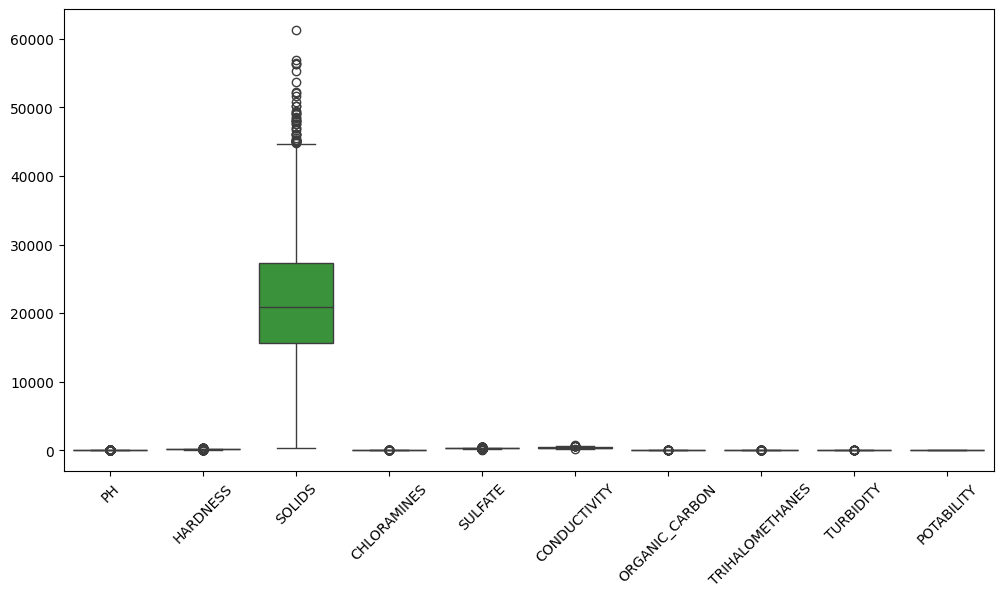

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

In [ ]:
from scipy.stats.mstats import winsorize
column=['SOLIDS','SULFATE','CONDUCTIVITY']
for c in column:
  df[c]=winsorize(df[c], limits=[0.1,0.1])
df




,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,7.036752,204.890456,20791.31898,7.300212,368.516441,533.303221,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.05786,6.635246,333.073546,533.303221,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.54173,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,363.266516,18.436525,100.341674,4.628771,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681736,33820.64576,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.80216,8.061362,333.073546,392.449580,19.903225,66.622485,2.798243,1
3273,9.419510,175.762646,33155.57822,7.350233,333.073546,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.86938,6.303357,333.073546,402.883113,11.168946,77.488213,4.708658,1


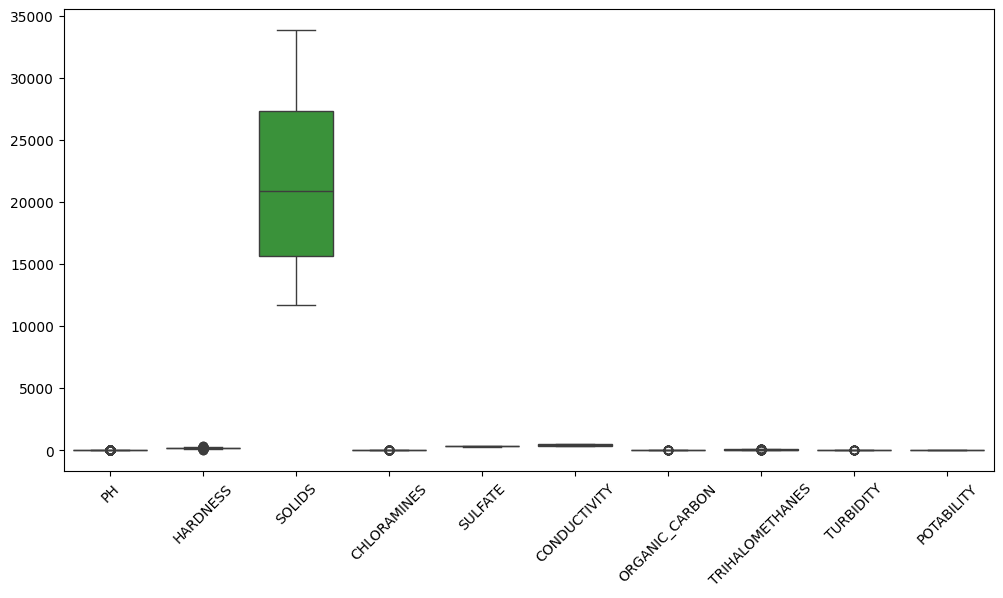

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

In [ ]:
from sklearn.preprocessing import PowerTransformer
columns=['PH','HARDNESS','CHLORAMINES','ORGANIC_CARBON','TRIHALOMETHANES','TURBIDITY']
pt=PowerTransformer(method='yeo-johnson')

for col in columns:
  df[[col]]=pt.fit_transform(df[[col]])
df


,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,-0.030891,0.250704,20791.31898,0.105823,368.516441,533.303221,-1.181554,1.319928,-1.285944,0
1,-2.260802,-2.006156,18630.05786,-0.314401,333.073546,533.303221,0.273844,-0.651478,0.683931,0
2,0.695232,0.846299,19909.54173,1.367419,333.073546,418.606213,0.782116,-0.014678,-1.167207,0
3,0.844614,0.541893,22018.41744,0.588372,356.886136,363.266516,1.252600,2.208299,0.848295,0
4,1.378473,-0.472936,17978.98634,-0.370235,310.135738,398.410813,-0.822605,-2.123390,0.138164,0
...,...,...,...,...,...,...,...,...,...,...
3271,-1.628694,-0.091512,33820.64576,0.021220,359.948574,526.424171,-0.114306,0.002384,0.600763,1
3272,0.496324,-0.095424,17329.80216,0.589666,333.073546,392.449580,1.691563,-0.001775,-1.496871,1
3273,1.604515,-0.633915,33155.57822,0.137529,333.073546,432.044783,-0.980601,0.204345,-0.856255,1
3274,-1.321891,1.043636,11983.86938,-0.523212,333.073546,402.883113,-0.941058,0.697830,0.950802,1


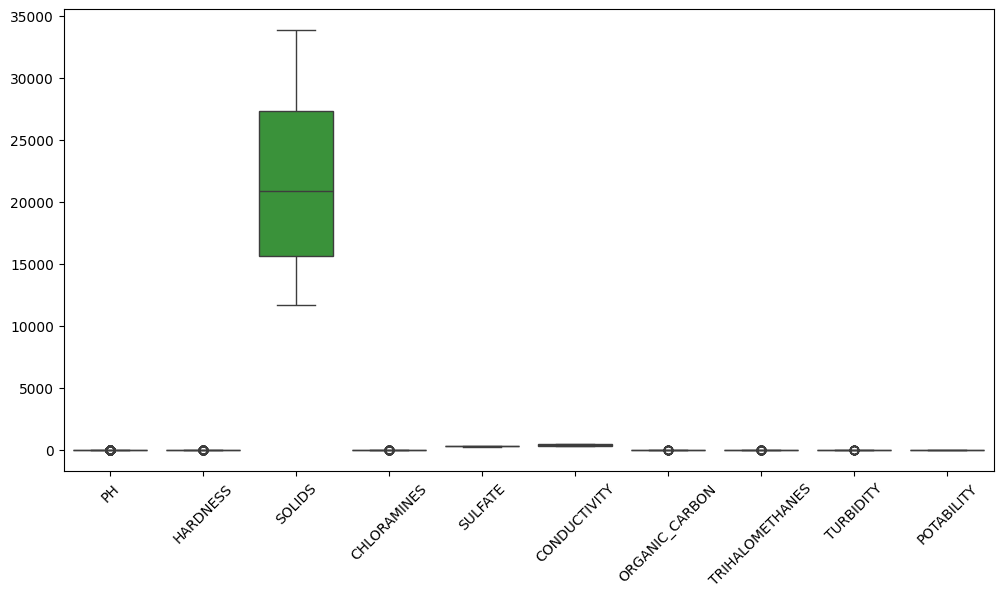

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

sc = StandardScaler()

scaled_df = pd.DataFrame(
    sc.fit_transform(df),
    columns=df.columns
)

scaled_df

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,-0.030891,0.250704,-0.131912,0.105823,1.327242,1.585177,-1.181554,1.319928,-1.285944,-0.799775
1,-2.260802,-2.006156,-0.434486,-0.314401,-0.021277,1.585177,0.273844,-0.651478,0.683931,-0.799775
2,0.695232,0.846299,-0.255360,1.367419,-0.021277,-0.092973,0.782116,-0.014678,-1.167207,-0.799775
3,0.844614,0.541893,0.039880,0.588372,0.884736,-0.902657,1.252600,2.208299,0.848295,-0.799775
4,1.378473,-0.472936,-0.525635,-0.370235,-0.894007,-0.388455,-0.822605,-2.123390,0.138164,-0.799775
...,...,...,...,...,...,...,...,...,...,...
3271,-1.628694,-0.091512,1.692177,0.021220,1.001255,1.484528,-0.114306,0.002384,0.600763,1.250352
3272,0.496324,-0.095424,-0.616520,0.589666,-0.021277,-0.475675,1.691563,-0.001775,-1.496871,1.250352
3273,1.604515,-0.633915,1.599068,0.137529,-0.021277,0.103649,-0.980601,0.204345,-0.856255,1.250352
3274,-1.321891,1.043636,-1.364943,-0.523212,-0.021277,-0.323020,-0.941058,0.697830,0.950802,1.250352


In [ ]:
X = df.drop(['POTABILITY'], axis=1)
y = df['POTABILITY']

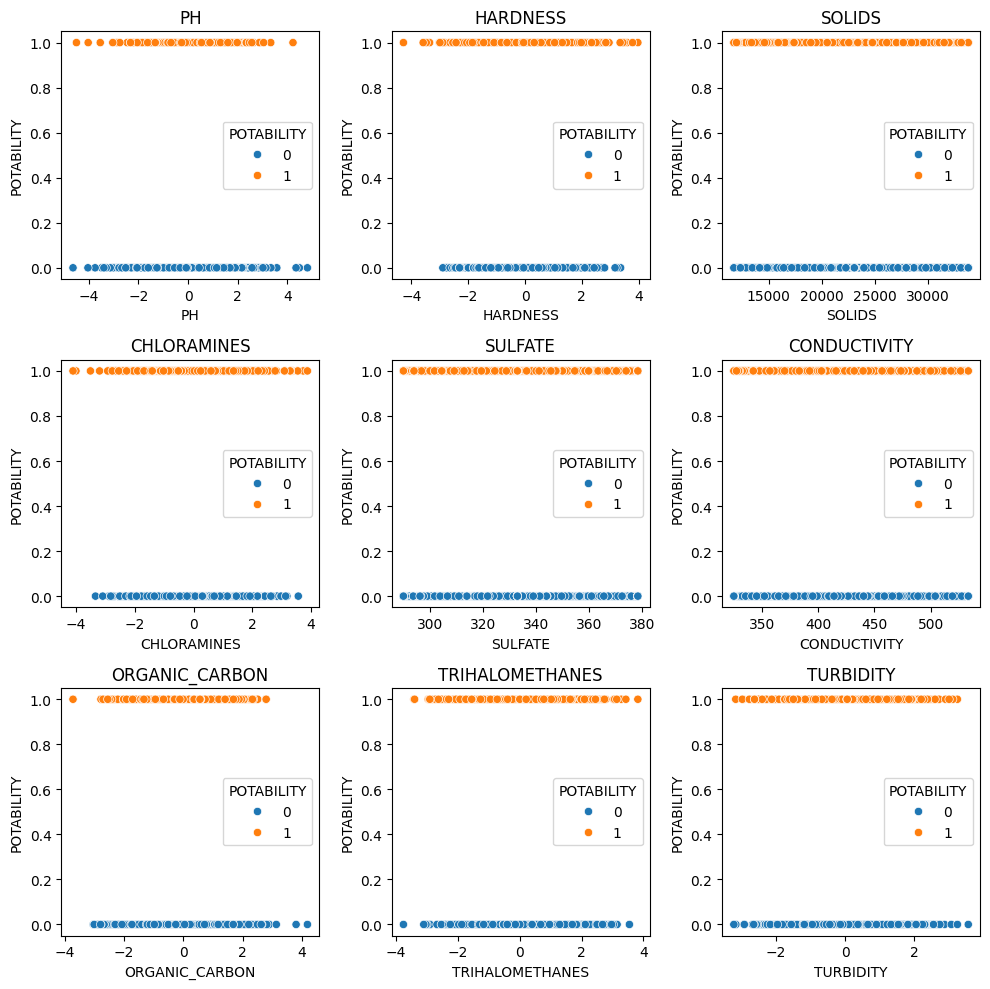

In [ ]:
cols = df.drop('POTABILITY', axis=1).columns

fig, ax = plt.subplots(3, 3, figsize=(10, 10))

axes = ax.flatten()

for c, current_ax in zip(cols, axes):
    sns.scatterplot(
        x=df[c],
        y=df['POTABILITY'],
        hue=df['POTABILITY'],
        ax=current_ax
    )

    current_ax.set_title(c)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=40)

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
from sklearn.svm import SVC

model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.6021341463414634

Confusion Matrix
[[395   0]
 [261   0]]

Classification Report
              precision    recall  f1-score   support

           0       0.60      1.00      0.75       395
           1       0.00      0.00      0.00       261

    accuracy                           0.60       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.36      0.60      0.45       656



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
